# Train the intrusion-detection models

Random Forest is the main algorithm. Decision Tree and K-Nearest Neighbors (KNN) are comparison models. All models perform binary classification: **benign (0)** or **attack (1)**.

In [6]:
from pathlib import Path
import json
import time

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay, RocCurveDisplay, accuracy_score,
    f1_score, precision_score, recall_score, roc_auc_score,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from tqdm.auto import tqdm

RANDOM_STATE = 42
TRAIN_SAMPLE_SIZE = None  # Random Forest and Decision Tree
KNN_TRAINING_ROWS = 25_000  # KNN is expensive during prediction
PREDICTION_BATCH_SIZE = 20_000
RUN_TRAINING = True

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

TRAIN_FILE = PROJECT_ROOT / "dataset/processed/train.parquet"
TEST_FILE = PROJECT_ROOT / "dataset/processed/test.parquet"
FEATURE_FILE = PROJECT_ROOT / "artifacts/feature_selection/selected_features.json"
OUTPUT_FOLDER = PROJECT_ROOT / "artifacts/models"

## 1. Load the selected features

In [3]:
feature_report = json.loads(FEATURE_FILE.read_text(encoding="utf-8"))
selected_features = feature_report["selected_features"]
print(f"Using {len(selected_features)} features:")
for number, feature in enumerate(selected_features, 1):
    print(f"{number:2}. {feature}")

Using 20 features:
 1. Packet Length Variance
 2. Packet Length Std
 3. Bwd Packet Length Std
 4. Average Packet Size
 5. Avg Bwd Segment Size
 6. Packet Length Mean
 7. Bwd Packet Length Max
 8. Bwd Packet Length Mean
 9. Max Packet Length
10. Destination Port
11. Fwd IAT Std
12. Fwd IAT Max
13. Flow IAT Max
14. Subflow Bwd Bytes
15. Total Length of Bwd Packets
16. Flow IAT Std
17. Idle Max
18. Fwd Packet Length Max
19. Init_Win_bytes_backward
20. Idle Mean


## 2. Load training and testing data

Only the selected feature columns and binary label are loaded. The optional training sample keeps the same benign/attack ratio. The complete test set is always retained.

In [7]:
def load_model_data(features, train_sample_size=500_000):
    columns = features + ["is_attack"]
    train = pd.read_parquet(TRAIN_FILE, columns=columns)
    test = pd.read_parquet(TEST_FILE, columns=columns)

    if train_sample_size and train_sample_size < len(train):
        benign = train[train["is_attack"] == 0]
        attacks = train[train["is_attack"] == 1]
        attack_rows = round(train_sample_size * len(attacks) / len(train))
        benign_rows = train_sample_size - attack_rows
        train = pd.concat([
            benign.sample(benign_rows, random_state=RANDOM_STATE),
            attacks.sample(attack_rows, random_state=RANDOM_STATE),
        ]).sample(frac=1, random_state=RANDOM_STATE)

    return (
        train[features], train["is_attack"],
        test[features], test["is_attack"],
    )

In [8]:
if RUN_TRAINING:
    x_train, y_train, x_test, y_test = load_model_data(
        selected_features, TRAIN_SAMPLE_SIZE
    )
    print(f"Training rows: {len(x_train):,}")
    print(f"Testing rows:  {len(x_test):,}")
    display(y_train.value_counts().rename(index={0: "Benign", 1: "Attack"}).to_frame("rows"))

Training rows: 2,016,638
Testing rows:  504,160


,rows
is_attack,
Benign,1676045
Attack,340593


## 3. Create the models

Class weights help the models learn from the smaller attack class. Tree depth is limited to reduce overfitting.

In [9]:
models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=100, max_depth=20, min_samples_leaf=2,
        class_weight="balanced_subsample", n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=20, min_samples_leaf=2, class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
    "K-Nearest Neighbors": make_pipeline(
        StandardScaler(),
        KNeighborsClassifier(n_neighbors=5, weights="distance", n_jobs=-1),
    ),
}
models

{'Random Forest': RandomForestClassifier(class_weight='balanced_subsample', max_depth=20,
                        min_samples_leaf=2, n_jobs=-1, random_state=42),
 'Decision Tree': DecisionTreeClassifier(class_weight='balanced', max_depth=20,
                        min_samples_leaf=2, random_state=42)}

## 4. Train and evaluate

In [10]:
def sample_training_data(x_train, y_train, sample_size):
    data = x_train.copy()
    data["is_attack"] = y_train.to_numpy()
    benign = data[data["is_attack"] == 0]
    attacks = data[data["is_attack"] == 1]
    attack_rows = round(sample_size * len(attacks) / len(data))
    benign_rows = sample_size - attack_rows
    sample = pd.concat([
        benign.sample(benign_rows, random_state=RANDOM_STATE),
        attacks.sample(attack_rows, random_state=RANDOM_STATE),
    ]).sample(frac=1, random_state=RANDOM_STATE)
    return sample.drop(columns="is_attack"), sample["is_attack"]


def predict_in_batches(model, x_test):
    predictions, probabilities = [], []
    positive_class = list(model.classes_).index(1)
    batches = range(0, len(x_test), PREDICTION_BATCH_SIZE)
    for start in tqdm(batches, desc="Predicting", unit="batch"):
        batch = x_test.iloc[start:start + PREDICTION_BATCH_SIZE]
        batch_probabilities = model.predict_proba(batch)
        predictions.append(model.classes_[np.argmax(batch_probabilities, axis=1)])
        probabilities.append(batch_probabilities[:, positive_class])
    return np.concatenate(predictions), np.concatenate(probabilities)


def evaluate_model(model, x_test, y_test):
    start = time.perf_counter()
    predictions, probabilities = predict_in_batches(model, x_test)
    prediction_seconds = time.perf_counter() - start

    metrics = {
        "accuracy": accuracy_score(y_test, predictions),
        "precision": precision_score(y_test, predictions, zero_division=0),
        "recall": recall_score(y_test, predictions, zero_division=0),
        "f1_score": f1_score(y_test, predictions, zero_division=0),
        "roc_auc": roc_auc_score(y_test, probabilities),
        "prediction_seconds": prediction_seconds,
    }
    return metrics, predictions, probabilities

Training Random Forest...


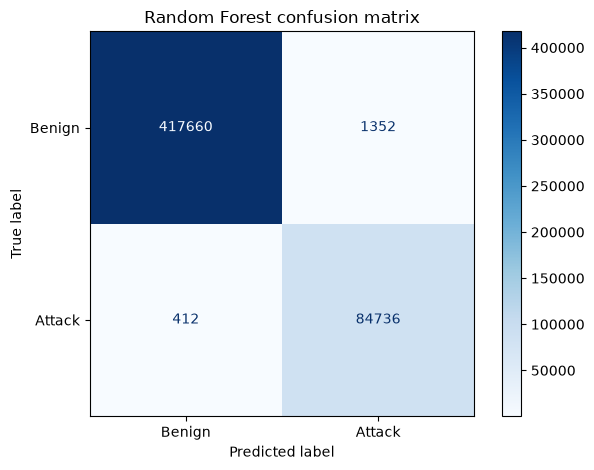

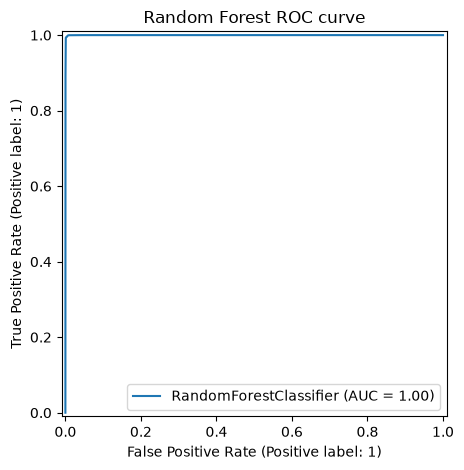

Training Decision Tree...


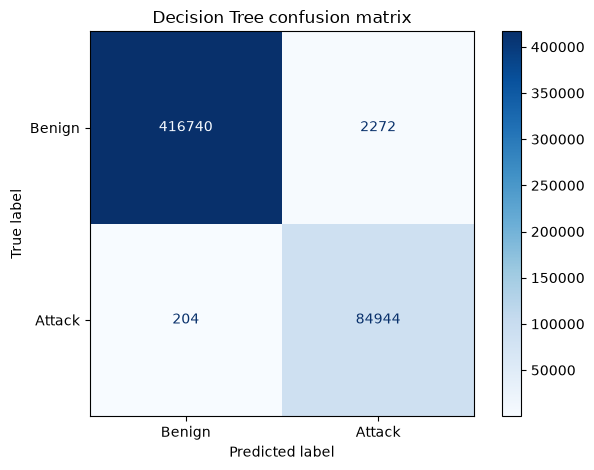

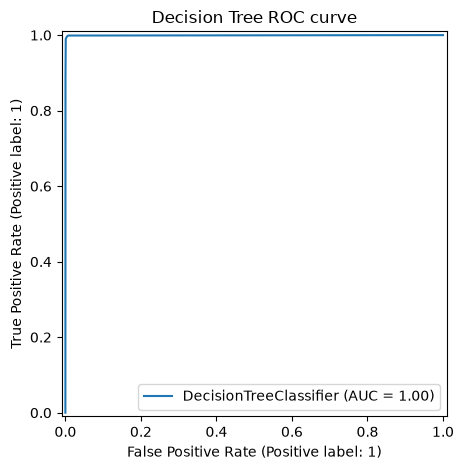

,accuracy,precision,recall,f1_score,roc_auc,prediction_seconds,training_rows,testing_rows,training_seconds
model,,,,,,,,,
Random Forest,0.9965,0.9843,0.9952,0.9897,0.9999,1.1640,2016638,504160,110.7722
Decision Tree,0.9951,0.9739,0.9976,0.9856,0.9993,0.0415,2016638,504160,29.4240


In [11]:
if RUN_TRAINING:
    OUTPUT_FOLDER.mkdir(parents=True, exist_ok=True)
    results = []

    for model_name, model in models.items():
        model_x_train, model_y_train = x_train, y_train
        if model_name == "K-Nearest Neighbors":
            model_x_train, model_y_train = sample_training_data(
                x_train, y_train, KNN_TRAINING_ROWS
            )

        print(f"Training {model_name} with {len(model_x_train):,} rows...")
        start = time.perf_counter()
        model.fit(model_x_train, model_y_train)
        training_seconds = time.perf_counter() - start

        metrics, predictions, probabilities = evaluate_model(model, x_test, y_test)
        metrics.update({
            "model": model_name,
            "training_rows": len(model_x_train),
            "testing_rows": len(x_test),
            "training_seconds": training_seconds,
        })
        results.append(metrics)

        file_name = model_name.lower().replace(" ", "_")
        joblib.dump(model, OUTPUT_FOLDER / f"{file_name}.joblib")

        ConfusionMatrixDisplay.from_predictions(
            y_test, predictions, display_labels=["Benign", "Attack"], cmap="Blues"
        )
        plt.title(f"{model_name} confusion matrix")
        plt.tight_layout()
        plt.savefig(OUTPUT_FOLDER / f"{file_name}_confusion_matrix.png", dpi=150)
        plt.show()

        RocCurveDisplay.from_predictions(y_test, probabilities)
        plt.title(f"{model_name} ROC curve")
        plt.tight_layout()
        plt.savefig(OUTPUT_FOLDER / f"{file_name}_roc_curve.png", dpi=150)
        plt.show()

    results = pd.DataFrame(results).set_index("model")
    results.to_csv(OUTPUT_FOLDER / "model_results.csv")
    display(results.round(4))

## 5. Save the training report

In [12]:
if RUN_TRAINING:
    training_report = {
        "main_model": "Random Forest",
        "selected_features": selected_features,
        "training_sample_size": TRAIN_SAMPLE_SIZE,
        "results": results.reset_index().to_dict(orient="records"),
    }
    (OUTPUT_FOLDER / "training_report.json").write_text(
        json.dumps(training_report, indent=2), encoding="utf-8"
    )
    print("Models and results saved in artifacts/models")

Models and results saved in artifacts/models


## 6. View existing results

In [13]:
result_file = OUTPUT_FOLDER / "model_results.csv"
if result_file.exists():
    saved_results = pd.read_csv(result_file, index_col="model")
    display(saved_results.round(4))
else:
    print("Set RUN_TRAINING = True and run the training cells.")

,accuracy,precision,recall,f1_score,roc_auc,prediction_seconds,training_rows,testing_rows,training_seconds
model,,,,,,,,,
Random Forest,0.9965,0.9843,0.9952,0.9897,0.9999,1.1640,2016638,504160,110.7722
Decision Tree,0.9951,0.9739,0.9976,0.9856,0.9993,0.0415,2016638,504160,29.4240


## Notes

- Random Forest is the main model.
- Decision Tree provides a simple performance baseline.
- The test set is untouched until final evaluation.
- Accuracy alone can hide missed attacks, so precision, recall, F1, and ROC-AUC are also reported.
- Set `TRAIN_SAMPLE_SIZE = None` to train with every training record.